## Authorship

- **Course / code author:** Xinze Li  
- **Tutorial article:** Xinze Li, Fanfan Lin, Juan J. Rodríguez-Andina, Sergio Vazquez, Homer Alan Mantooth, Leopoldo García Franquelo, "Fundamentals of Artificial Intelligences for Power Electronics," *IEEE Transactions on Industrial Electronics*, 2026.

*These learning resources are still under active refinement; notebooks, data, and documentation may change.*

---



## DQN-based voltage control of a buck converter (toy example)

**Authorship:** course materials — *Fundamentals of AI for PE*.

This notebook trains a **Deep Q-Network (DQN)** agent to command the **duty cycle** of an ideal **averaged** buck so that **output voltage** tracks a reference. Actions are **discrete** (small steps in $D$). Only **NumPy** and **PyTorch** are required.

### Training (full stabilized recipe)
**Experience replay** and a **target network** (periodic hard sync) are standard DQN. We also use **Double DQN** (online net picks the action, target net evaluates it), **Huber loss** on the TD error, **clipped TD targets** for stability, **gradient clipping**, **clipped rewards** in the environment, and an in-memory **best-policy checkpoint** (highest episode return) restored at the end of training.

### Plant model (continuous conduction, averaged)
State internal to the environment is $[i_L, v_{out}, D]^\top$. With duty $D \in [D_{min}, D_{max}]$ and input $V_{in}$:
- $\dot{i}_L = (D V_{in} - v) / L$
- $\dot{v} = (i_L - v/R) / C$

On each **reset**, **$V_{in}$** is sampled from a configurable range (so the policy sees **different input voltages**), together with random $v_{ref}$, $v_{out}(0)$, $i_L(0)$, and initial $D$.

> **Note:** Pedagogical surrogate — not a switching simulator. For hardware, add constraints, observers, and validation.


In [1]:
import math
import random
from collections import deque
from typing import Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [2]:
class BuckAvgEnv:
    """Averaged buck — discrete actions are duty increments (delta D), clipped to [d_min, d_max]."""

    def __init__(
        self,
        Vin: float = 12.0,
        vin_range: Tuple[float, float] = (8.0, 24.0),
        L: float = 120e-6,
        C: float = 220e-6,
        R: float = 2.0,
        dt: float = 5e-6,
        d_min: float = 0.06,
        d_max: float = 0.92,
        max_episode_steps: int = 240,
        n_actions: int = 9,
    ):
        self.Vin_nom = float(Vin)
        self.vin_min, self.vin_max = float(vin_range[0]), float(vin_range[1])
        assert self.vin_min < self.vin_max
        self.L = L
        self.C = C
        self.R = R
        self.dt = dt
        self.d_min = d_min
        self.d_max = d_max
        self.max_episode_steps = max_episode_steps

        self.n_actions = int(n_actions)
        self.delta_d = np.linspace(-0.04, 0.04, self.n_actions).astype(np.float64)

        self.Vin = self.Vin_nom
        self._rescale_for_vin()
        self.step_count = 0
        self.state = None
        self.v_ref = 5.0

    def _rescale_for_vin(self):
        self.i_scale = self.Vin * self.d_max / max(self.R, 1e-6) * 1.5
        self.v_scale = max(self.Vin, 1e-6)

    def _observe(self):
        iL, v, D = self.state
        err = (v - self.v_ref) / self.v_scale
        d_n = (D - self.d_min) / max(self.d_max - self.d_min, 1e-6)
        return np.array(
            [
                err,
                iL / max(self.i_scale, 1e-6),
                float(d_n),
                self.v_ref / self.v_scale,
                self.Vin / self.vin_max,
            ],
            dtype=np.float32,
        )

    def reset(self, seed: Optional[int] = None):
        if seed is not None:
            np.random.seed(seed)
            random.seed(seed)
        self.Vin = float(np.random.uniform(self.vin_min, self.vin_max))
        self._rescale_for_vin()
        self.v_ref = float(np.random.uniform(0.22, 0.78) * self.Vin)
        v0 = float(np.random.uniform(0.03 * self.Vin, 0.97 * self.Vin))
        i0 = float(np.random.uniform(0.0, self.i_scale * 0.9))
        D0 = float(np.random.uniform(self.d_min, self.d_max))
        self.state = np.array([i0, v0, D0], dtype=np.float64)
        self.step_count = 0
        return self._observe(), {}

    def step(self, action: int):
        a = int(np.clip(action, 0, self.n_actions - 1))
        iL, v, D_prev = self.state
        D = float(np.clip(D_prev + self.delta_d[a], self.d_min, self.d_max))

        di = (D * self.Vin - v) / self.L
        dv = (iL - v / self.R) / self.C
        noise = np.random.randn(2) * np.array(
            [self.i_scale * 2e-4, self.v_scale * 1e-4]
        )
        iL = iL + self.dt * di + noise[0]
        v = v + self.dt * dv + noise[1]
        iL = float(np.clip(iL, 0.0, self.i_scale))
        v = float(np.clip(v, 0.0, self.Vin))
        self.state = np.array([iL, v, D], dtype=np.float64)
        self.step_count += 1

        err = v - self.v_ref
        r_track = -float(err**2)
        r_i = -1e-4 * (iL / max(self.i_scale, 1e-6)) ** 2
        reward = float(np.clip(r_track + r_i, -50.0, 0.0))

        terminated = bool(v < 0.02 * self.v_ref or v > 1.08 * self.Vin)
        truncated = self.step_count >= self.max_episode_steps
        return self._observe(), reward, terminated, truncated, {}


env = BuckAvgEnv()
o0, _ = env.reset(seed=0)
print("obs dim:", o0.shape, "n_actions:", env.n_actions, "Vin range:", env.vin_min, "-", env.vin_max)


obs dim: (5,) n_actions: 9 Vin range: 8.0 - 24.0


In [7]:
from collections import deque
import copy
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim


class ReplayBufferDQN:
    def __init__(self, capacity: int):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, s2, done):
        self.buf.append((s, int(a), float(r), s2, float(done)))

    def sample(self, batch_size: int):
        batch = random.sample(self.buf, batch_size)
        s, a, r, s2, d = zip(*batch)
        return (
            torch.tensor(np.stack(s), device=device, dtype=torch.float32),
            torch.tensor(a, device=device, dtype=torch.long),
            torch.tensor(r, device=device, dtype=torch.float32).unsqueeze(1),
            torch.tensor(np.stack(s2), device=device, dtype=torch.float32),
            torch.tensor(d, device=device, dtype=torch.float32).unsqueeze(1),
        )

    def __len__(self):
        return len(self.buf)


class QNetwork(nn.Module):
    def __init__(self, n_obs: int, n_actions: int, hidden: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_obs, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        # BatchNorm layers have been removed

    def forward(self, x):
        # No need for extra handling for BatchNorm
        if x.dim() == 1:
            x = x.unsqueeze(0)
        return self.net(x)


def linear_eps(step: int, total: int, eps_start: float, eps_end: float) -> float:
    if total <= 1:
        return eps_end
    frac = min(1.0, step / float(total))
    return eps_start + frac * (eps_end - eps_start)


def train_dqn(
    env: BuckAvgEnv,
    total_steps: int = 55_000,
    warmup: int = 6_000,
    batch_size: int = 128,
    gamma: float = 0.99,
    lr: float = 1e-3,
    target_update: int = 500,
    eps_start: float = 1.0,
    eps_end: float = 0.05,
    seed: int = 7,
    grad_clip: float = 1.0,
):
    """Stabilized DQN: Double DQN, target net, Huber, grad clip, TD clamp, in-memory best policy, train every 4 steps after warmup."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    s, _ = env.reset(seed=seed)
    n_obs = s.shape[0]
    n_a = env.n_actions

    policy_net = QNetwork(n_obs, n_a).to(device)
    target_net = QNetwork(n_obs, n_a).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    opt = optim.Adam(policy_net.parameters(), lr=lr, betas=(0.9, 0.999))
    buffer = ReplayBufferDQN(100_000)

    returns = []
    ep_return = 0.0
    a = 0

    monitor = {"step": [], "loss": [], "q_mean": [], "td_abs": [], "eps": [], "buffer": []}
    best_ret = -float("inf")
    best_state = None

    for t in range(1, total_steps + 1):
        eps = linear_eps(t, total_steps, eps_start, eps_end)
        with torch.no_grad():
            policy_net.eval()
            qs = policy_net(torch.tensor(s, device=device, dtype=torch.float32).unsqueeze(0))
            policy_net.train()
        if random.random() < eps:
            a = random.randrange(n_a)
        else:
            a = int(qs.argmax(dim=1).item())

        s2, r, term, trunc, _ = env.step(a)
        done = float(term or trunc)
        buffer.push(s, a, r, s2, done)
        ep_return += r
        s = s2
        if term or trunc:
            returns.append(ep_return)
            if ep_return > best_ret:
                best_ret = ep_return
                best_state = copy.deepcopy(policy_net.state_dict())
            ep_return = 0.0
            s, _ = env.reset()

        loss_v = float("nan")
        q_mean_v = float("nan")
        td_abs_v = float("nan")

        if len(buffer) >= warmup and t % 4 == 0:
            bs, ba, br, bs2, bd = buffer.sample(batch_size)
            policy_net.train()
            target_net.eval()
            with torch.no_grad():
                next_a = policy_net(bs2).argmax(dim=1, keepdim=True)
                next_q = target_net(bs2).gather(1, next_a)
                y = br + gamma * (1.0 - bd) * next_q
                y = torch.clamp(y, -100.0, 100.0)
            q = policy_net(bs).gather(1, ba.unsqueeze(1))
            loss = nn.functional.smooth_l1_loss(q, y)
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(policy_net.parameters(), grad_clip)
            opt.step()
            loss_v = loss.item()
            q_mean_v = q.mean().item()
            td_abs_v = (q.detach() - y).abs().mean().item()

        if t % target_update == 0:
            target_net.load_state_dict(policy_net.state_dict())

        if t % 500 == 0:
            iL, v, D = env.state
            last_ret = returns[-1] if returns else float("nan")
            print(
                f"step {t}  eps={eps:.3f}  buf={len(buffer)}  loss={loss_v:.4f}  "
                f"Q_mean={q_mean_v:.3f}  |TD|={td_abs_v:.4f}  "
                f"Vin={env.Vin:.2f}  v_ref={env.v_ref:.2f}  v={v:.3f}  D={D:.3f}  a={a}  ep_ret(last)={last_ret:.1f}"
            )
            monitor["step"].append(t)
            monitor["loss"].append(loss_v)
            monitor["q_mean"].append(q_mean_v)
            monitor["td_abs"].append(td_abs_v)
            monitor["eps"].append(eps)
            monitor["buffer"].append(len(buffer))

    if best_state is not None:
        policy_net.load_state_dict(best_state)
        print(f"Restored best policy weights (episode return={best_ret:.1f}).")
    return policy_net, returns, monitor


train_env = BuckAvgEnv()
q_net, episode_returns, train_monitor = train_dqn(train_env, total_steps=150_000, seed=7)
print("trained episodes logged:", len(episode_returns))


step 500  eps=0.997  buf=500  loss=nan  Q_mean=nan  |TD|=nan  Vin=10.07  v_ref=3.99  v=8.065  D=0.123  a=4  ep_ret(last)=-1338.5
step 1000  eps=0.994  buf=1000  loss=nan  Q_mean=nan  |TD|=nan  Vin=20.11  v_ref=12.62  v=10.592  D=0.070  a=2  ep_ret(last)=-7028.2
step 1500  eps=0.991  buf=1500  loss=nan  Q_mean=nan  |TD|=nan  Vin=16.88  v_ref=4.43  v=7.098  D=0.083  a=2  ep_ret(last)=-1968.5
step 2000  eps=0.987  buf=2000  loss=nan  Q_mean=nan  |TD|=nan  Vin=18.48  v_ref=11.59  v=16.755  D=0.850  a=5  ep_ret(last)=-899.5
step 2500  eps=0.984  buf=2500  loss=nan  Q_mean=nan  |TD|=nan  Vin=19.39  v_ref=11.22  v=4.205  D=0.160  a=4  ep_ret(last)=-2912.3
step 3000  eps=0.981  buf=3000  loss=nan  Q_mean=nan  |TD|=nan  Vin=9.03  v_ref=2.25  v=2.029  D=0.230  a=0  ep_ret(last)=-3536.0
step 3500  eps=0.978  buf=3500  loss=nan  Q_mean=nan  |TD|=nan  Vin=12.22  v_ref=7.21  v=3.284  D=0.060  a=0  ep_ret(last)=-1968.5
step 4000  eps=0.975  buf=4000  loss=nan  Q_mean=nan  |TD|=nan  Vin=19.69  v_ref=6

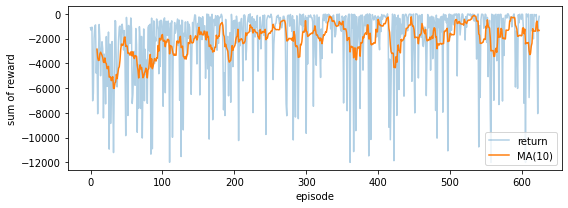

In [8]:
plt.figure(figsize=(8, 3))
plt.plot(episode_returns, alpha=0.35, label="return")
if len(episode_returns) >= 10:
    win = 10
    smoothed = np.convolve(episode_returns, np.ones(win) / win, mode="valid")
    plt.plot(range(win - 1, len(episode_returns)), smoothed, label=f"MA({win})")
plt.xlabel("episode"); plt.ylabel("sum of reward"); plt.legend(); plt.tight_layout(); plt.show()

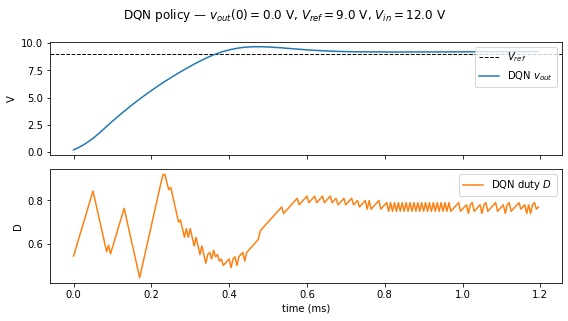

In [21]:
def rollout_deterministic(
    env: BuckAvgEnv,
    q_net: QNetwork,
    v_ref: float,
    v0: float,
    vin: Optional[float] = None,
    i0: Optional[float] = None,
    D0: Optional[float] = None,
    seed: int = 999,
):
    """Greedy DQN rollout at fixed v_ref and v0; optional fixed Vin (clamped to env range)."""
    np.random.seed(seed)
    random.seed(seed)
    if vin is not None:
        env.Vin = float(np.clip(vin, env.vin_min, env.vin_max))
        env._rescale_for_vin()
    env.v_ref = float(v_ref)
    v0 = float(np.clip(v0, 0.01 * env.Vin, 0.99 * env.Vin))
    if i0 is None:
        i0 = float(np.random.uniform(0.0, env.i_scale * 0.5))
    else:
        i0 = float(np.clip(i0, 0.0, env.i_scale))
    if D0 is None:
        D0 = float(np.random.uniform(env.d_min, env.d_max))
    else:
        D0 = float(np.clip(D0, env.d_min, env.d_max))
    env.state = np.array([i0, v0, D0], dtype=np.float64)
    env.step_count = 0
    obs = env._observe()

    log = {"v": [], "d": [], "iL": []}
    for _ in range(env.max_episode_steps):
        with torch.no_grad():
            qs = q_net(torch.tensor(obs, device=device, dtype=torch.float32).unsqueeze(0))
            a = int(qs.argmax(dim=1).item())
        obs, _, term, trunc, _ = env.step(a)
        iL, v, D = env.state
        log["v"].append(v)
        log["d"].append(D)
        log["iL"].append(iL)
        if term or trunc:
            break
    return log

eval_env = BuckAvgEnv()
target_v = 9.0
v_init = 0.0
trace = rollout_deterministic(eval_env, q_net, v_ref=target_v, v0=v_init, vin=12.0, seed=999)

t_axis = np.arange(len(trace["v"])) * eval_env.dt * 1e3

fig, ax = plt.subplots(2, 1, figsize=(8, 4.5), sharex=True)
ax[0].axhline(target_v, color="k", ls="--", lw=1, label=r"$V_{ref}$")
ax[0].plot(t_axis, trace["v"], label=r"DQN $v_{out}$")
ax[0].set_ylabel("V")
ax[0].legend(loc="upper right")
ax[1].plot(t_axis, trace["d"], color="C1", label=r"DQN duty $D$")
ax[1].set_ylabel("D")
ax[1].set_xlabel("time (ms)")
ax[1].legend(loc="upper right")
plt.suptitle(
    rf"DQN policy — $v_{{out}}(0)={v_init}$ V, $V_{{ref}}={target_v}$ V, $V_{{in}}={eval_env.Vin:.1f}$ V"
)
plt.tight_layout()
plt.show()

